In [582]:
import numpy as np
from astropy import units as u
from astropy.constants import c
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [593]:
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = '12'
rcParams['font.style'] = 'normal'
rcParams['font.weight'] = 'medium'
rcParams['pdf.fonttype'] = '42'

rcParams['grid.linestyle'] = ':'
rcParams['grid.linewidth'] = 1.25
rcParams['grid.alpha'] = 0.5

rcParams['lines.linewidth'] = 2

rcParams['axes.xmargin'] = 0
rcParams['axes.ymargin'] = 0
rcParams['axes.axisbelow'] = True

rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'

rcParams["figure.frameon"] = False
# rcParams["figure.figsize"] = (9.5,6.5)
rcParams["figure.dpi"] = 85

# rcParams['text.usetex'] = False

# rcParams["figure.figsize"] = [6.4, 4.8]
# rcParams['figure.autolayout'] = True

def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i/inch for i in tupl[0])
    else:
        return tuple(i/inch for i in tupl)

In [691]:
def H(ω0, J, δ1, δ2 = 0):
    return np.array([
        [ω0 + δ1, -J, 0],
        [-J, ω0, -J],
        [0, -J, ω0 -δ1+ δ2], #-δ1
    ])

def coupled_basis(ω0, J, δ1, δ2 = 0, freqstoo = False):
    eigenfreq, eigenvec = np.linalg.eig(H(ω0, J, δ1, δ2))
    eigenvec = eigenvec.T

    idx = eigenfreq.argsort()  

    eigenfreq = eigenfreq[idx]
    eigenvec = eigenvec[idx]

    for ind in range(3):
        if eigenvec[ind][0] < 0:
            eigenvec[ind] = -eigenvec[ind]
    if freqstoo:
        return eigenvec, eigenfreq
    return eigenvec
    # return eigenfrequencies

def Integrand(α, β, γ, μ, ω0, J, δ1, δ2 = 0):
    e = coupled_basis(ω0, J, δ1, δ2)
    integrand =  np.dot(e[μ-1]*e[α-1], e[β-1]*e[γ-1])
    return integrand

def f(α, β, γ, μ, ω0, J, δ1, δ2=0):
    return Integrand(α, β, γ, μ, ω0, J, δ1, δ2)/Integrand(2,2,2,2, ω0, J, δ1, δ2)

np.array([
    [f(1,1,1,1, 0,1,0), f(2,2,1,1, 0,1,0), f(3,3,1,1, 0,1,0)],
    [f(1,1,2,2, 0,1,0), f(2,2,2,2, 0,1,0), f(3,3,2,2, 0,1,0)],
    [f(1,1,3,3, 0,1,0), f(2,2,3,3, 0,1,0), f(3,3,3,3, 0,1,0)]
])
    

array([[0.75, 0.5 , 0.75],
       [0.5 , 1.  , 0.5 ],
       [0.75, 0.5 , 0.75]])

In [692]:
def phase_shift(ω0, J, δ):
    ΔS = f(1, 1, 1, 1, ω0, J, δ) +  2 * f(3, 3, 1, 1, ω0, J, δ)
    ΔC = 2 * f(1, 1, 2, 2, ω0, J, δ) + 2 * f(3, 3, 2, 2, ω0, J, δ)
    ΔAS = 2* f(1, 1, 3, 3, ω0, J, δ) + f(3, 3, 3, 3, ω0, J, δ)

    return ΔS, ΔC, ΔAS

def phase_shift_S(ω0, J, δ1, δ2=0):
    ΔS = f(1, 1, 1, 1, ω0, J, δ1, δ2) + 2 * f(3, 3, 1, 1, ω0, J, δ1, δ2)

    return ΔS

def phase_shift_C(ω0, J, δ1, δ2=0):
    ΔC = 2 * f(1, 1, 2, 2, ω0, J, δ1, δ2) + 2 * f(3, 3, 2, 2, ω0, J, δ1, δ2)

    return ΔC

def phase_shift_AS(ω0, J, δ1, δ2=0):
    ΔAS = 2* f(1, 1, 3, 3, ω0, J, δ1, δ2) + f(3, 3, 3, 3, ω0, J, δ1, δ2)

    return ΔAS

def J2(ω0, J, δ1, δ2=0):
    eigenfreq, _ = np.linalg.eig(H(ω0, J, δ1, δ2))
    eigenfreq = np.sort(eigenfreq)

    J2 = (eigenfreq[2] - eigenfreq[1]) - (eigenfreq[1] - eigenfreq[0])

    return J2

In [693]:
ω0 = 10
J = 10
δ = 0

ΔS, ΔC, ΔAS = phase_shift(ω0, J, δ)

print(ΔS, ΔC, ΔAS)

2.2499999999999996 2.0 2.2499999999999996


In [694]:
J1/κ

<Quantity 11.7442716>

In [695]:
λ0 = 1560 * u.nm
f0 = (c/λ0).to(u.THz)
ω0 = (2*np.pi) * f0
κ = 5.35 * u.GHz # including 2 pi
J = (2*np.pi) * (10 / np.sqrt(2)) * u.GHz
J1 = J * np.sqrt(2) # including 2 pi

δ = np.linspace(-J1/κ,J1/κ, 100)

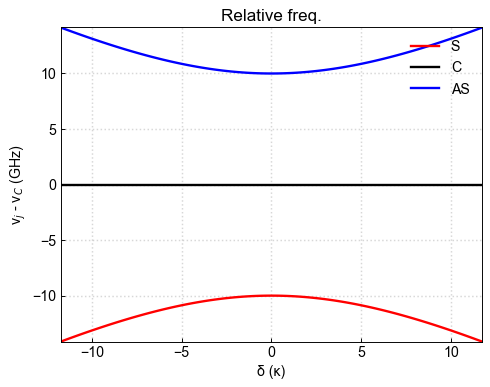

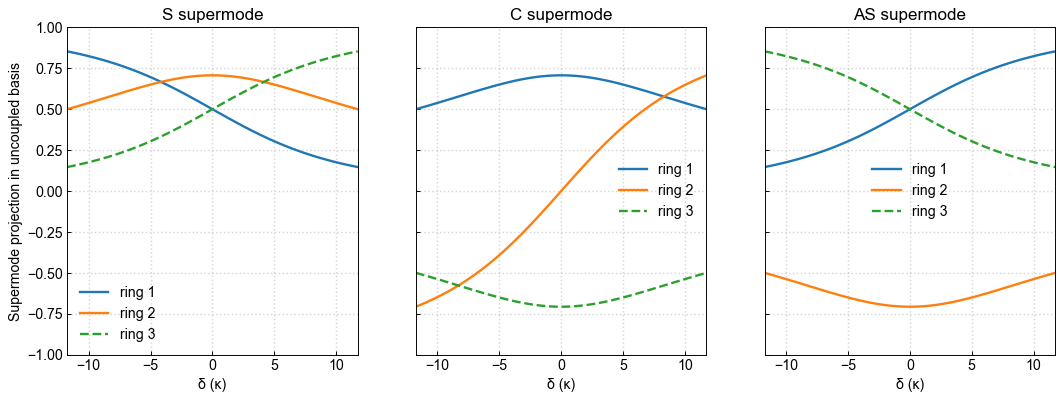

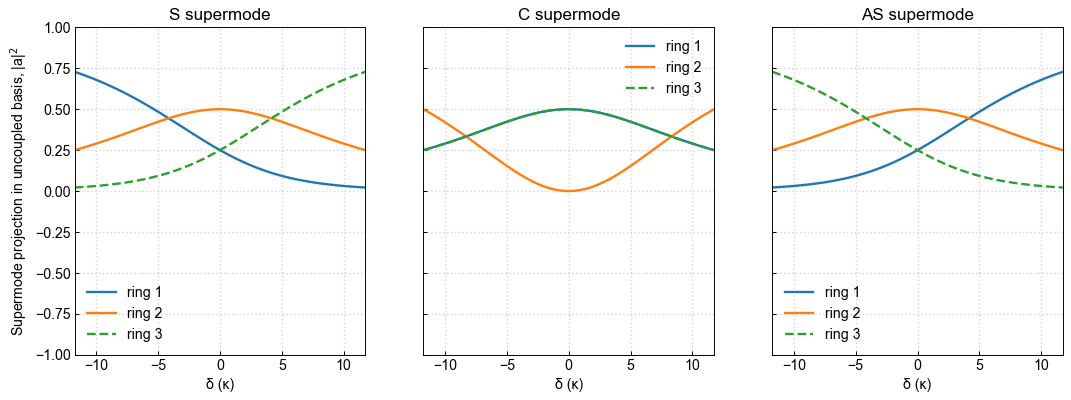

In [696]:
δ = np.linspace(-(J1/κ).value,(J1/κ).value, 100)
# δ = np.linspace(-.5, .5, 100)

supermodes = [coupled_basis(ω0.to(u.Hz).value, J.to(u.Hz).value, δi*κ.to(u.Hz).value) for δi in δ]
supermodes = np.array(supermodes)

eigenfrequencies = [coupled_basis(ω0.to(u.Hz).value, J.to(u.Hz).value, δi*κ.to(u.Hz).value, freqstoo=True)[1] for δi in δ]
eigenfrequencies = np.array(eigenfrequencies)

ωS = eigenfrequencies[:,0] * u.Hz
ωC = eigenfrequencies[:,1] * u.Hz
ωAS = eigenfrequencies[:,2] * u.Hz

plt.plot(δ, (ωS - ωC).to(u.GHz)/(2*np.pi), 'r', label = 'S')
plt.plot(δ, (ωC - ωC).to(u.GHz)/(2*np.pi), 'k', label = 'C')
plt.plot(δ, (ωAS - ωC).to(u.GHz)/(2*np.pi), 'b', label = 'AS')
plt.title('Relative freq.')
plt.xlabel('δ (κ)')
plt.ylabel('ν$_j$ - ν$_C$ (GHz)')
plt.grid(True, axis = 'both')
plt.legend(frameon = False)
plt.show()

fig, ax = plt.subplots(1,3, sharex = 'all', sharey = 'all', figsize = (15,5))

ax[0].set_title('S supermode')
ax[1].set_title('C supermode')
ax[2].set_title('AS supermode')
for ind in range(3):
    ax[ind].plot(δ, supermodes[:,ind,0], label = 'ring 1')
    ax[ind].plot(δ, supermodes[:,ind,1], label = 'ring 2')
    ax[ind].plot(δ, supermodes[:,ind,2], '--', label = 'ring 3')
    ax[ind].legend(frameon = False)
    ax[ind].set_xlabel('δ (κ)')
    ax[ind].grid(True, axis = 'both')
ax[0].set_ylabel('Supermode projection in uncoupled basis')
ax[2].set_ylim(-1,1)

fig, ax = plt.subplots(1,3, sharex = 'all', sharey = 'all', figsize = (15,5))

ax[0].set_title('S supermode')
ax[1].set_title('C supermode')
ax[2].set_title('AS supermode')
for ind in range(3):
    ax[ind].plot(δ, supermodes[:,ind,0]**2, label = 'ring 1')
    ax[ind].plot(δ, supermodes[:,ind,1]**2, label = 'ring 2')
    ax[ind].plot(δ, supermodes[:,ind,2]**2, '--', label = 'ring 3')
    ax[ind].legend(frameon = False)
    ax[ind].set_xlabel('δ (κ)')
    ax[ind].grid(True, axis = 'both', linewidth = 1.25)
ax[0].set_ylabel('Supermode projection in uncoupled basis, |a|$^2$')
ax[2].set_ylim(-1,1)
plt.grid(True, axis = 'both')

(-3.0, 3.0)

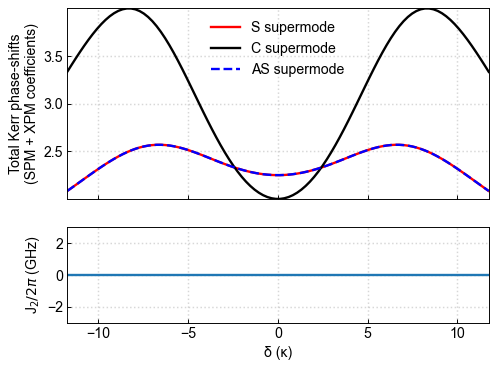

In [697]:
# δ = np.linspace(-100, 100, 1000)
δ = np.linspace(-(J1/κ).value,(J1/κ).value, 100)
# δ = np.linspace(-.5, .5, 100)

ΔS = [phase_shift_S(ω0.to(u.Hz).value, J.to(u.Hz).value, δi*κ.to(u.Hz).value) for δi in δ]
ΔC = [phase_shift_C(ω0.to(u.Hz).value, J.to(u.Hz).value, δi*κ.to(u.Hz).value) for δi in δ]
ΔAS = [phase_shift_AS(ω0.to(u.Hz).value, J.to(u.Hz).value, δi*κ.to(u.Hz).value) for δi in δ]

J2_vec = [J2(ω0.to(u.Hz).value, J.to(u.Hz).value, δi*κ.to(u.Hz).value) for δi in δ]*u.Hz

fig, ax = plt.subplots(2,1, sharex = 'all', gridspec_kw={'height_ratios':[3,1.5]})

ax[0].plot(δ, ΔS, 'r', label = 'S supermode')
ax[0].plot(δ, ΔC, 'k', label = 'C supermode')
ax[0].plot(δ, ΔAS, '--b', label = 'AS supermode')
ax[0].set_ylabel('Total Kerr phase-shifts\n(SPM + XPM coefficients)')
ax[0].legend(frameon = False)
ax[0].grid(True, axis = 'both')
# ax[0].set_ylim(1, 3)

ax[1].plot(δ, (J2_vec).to(u.GHz)/(2*np.pi))
# ax[1].axhline(0, linestyle = 'dashed', color = 'black', alpha = .1)
ax[1].set_xlabel('δ (κ)')
ax[1].set_ylabel('J$_2/2\pi$ (GHz)')
ax[1].grid(True, axis = 'both')
ax[1].set_ylim(-3, 3)

In [644]:
def KerrDif(ω0, J, δ1, δ2=0):
    diff = np.average([phase_shift_S(ω0, J, δ1, δ2), phase_shift_AS(ω0, J, δ1, δ2)]) - phase_shift_C(ω0, J, δ1, δ2)

    return diff

δ = np.linspace(-J1/κ,J1/κ, 100)
δ1 = 0
δ2 = 0

KerrDif(ω0.to(u.Hz).value, J.to(u.Hz).value, δ1*κ.to(u.Hz).value, δ2*κ.to(u.Hz).value)

0.2500000000032889

In [675]:
δ1 = np.linspace(-(J1/κ).value,(J1/κ).value, 100)
δ2 = np.linspace(-(J1/κ).value,(J1/κ).value, 100)

# δ1 = np.linspace(-100, 100, 100)
# δ2 = np.linspace(-100, 100, 100)

KerrDif_vec = [[KerrDif(ω0.to(u.Hz).value, J.to(u.Hz).value, δ1i*κ.to(u.Hz).value, δ2i*κ.to(u.Hz).value) for δ1i in δ1] for δ2i in δ2]
J2_vec = [[J2(ω0.to(u.Hz).value, J.to(u.Hz).value, δ1i*κ.to(u.Hz).value, δ2i*κ.to(u.Hz).value) for δ1i in δ1] for δ2i in δ2]*u.Hz

δ1, δ2 = np.meshgrid(δ1, δ2)

C:\Users\lucat\AppData\Local\Temp\ipykernel_8248\3964755549.py:2: UserWarning: Adding colorbar to a different Figure <Figure size 544x408 with 2 Axes> than <Figure size 544x408 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(im)


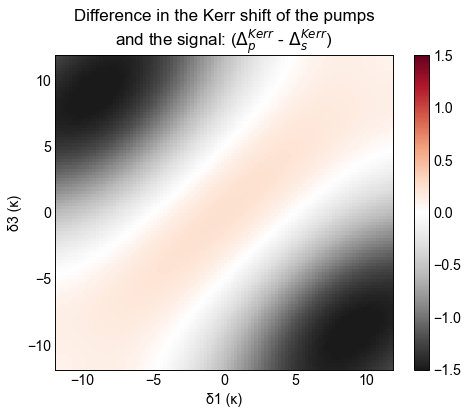

C:\Users\lucat\AppData\Local\Temp\ipykernel_8248\3964755549.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 544x408 with 2 Axes> than <Figure size 544x408 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(im)


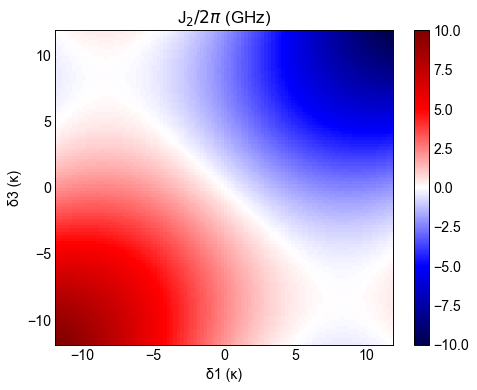

In [676]:
im = plt.pcolormesh(δ1, δ2, KerrDif_vec, cmap = 'RdGy_r', vmin=-1.5, vmax=1.5)
fig.colorbar(im)

plt.title('Difference in the Kerr shift of the pumps\nand the signal: ($\Delta^{Kerr}_p$ - $\Delta^{Kerr}_s$)')
plt.xlabel('δ1 (κ)')
plt.ylabel('δ3 (κ)')

plt.show()

im = plt.pcolormesh(δ1, δ2, (J2_vec).to(u.GHz).value/(2*np.pi), cmap = 'seismic', vmin=-10, vmax=10)
fig.colorbar(im)

plt.title('J$_2/2\pi$ (GHz)')
plt.xlabel('δ1 (κ)')
plt.ylabel('δ3 (κ)')

plt.show()